# Introduction

This project tackles common sense question answering using the [CommonsenseQA](https://huggingface.co/datasets/tau/commonsense_qa) dataset. The goal is to train and evaluate two different neural network architectures:

<span style="color:red">// TODO: adjust architecture description based on implementation</span>
1. A simple classifier using pre-trained word embeddings (Word2Vec)
2. A recurrent neural network (GRU) with word embeddings

This notebook implements both architectures, evaluates their performance, and analyzes the results.

## Dataset

[CommonsenseQA](https://huggingface.co/datasets/tau/commonsense_qa) is a multiple-choice question answering dataset that requires common sense knowledge to select the correct answer from five choices.

### Data Analysis

To build the model architecutre it is useful to know the token length of the longest question. To make an estimation we take the longest question from the dataset (Hugging Face Data Studio) and split it by spaces to count the items which is an estimate to tokens.

In [25]:
longest_question = """Laura and Bob are a married couple who have begun reaching tentative agreement 
    regarding their sexual incompatibility. They love each other and want to remain together, but 
    have decided that they can see other people to fulfill their needs as long as they are honest 
    about it. Then entire negotiation is being done with a surprising amount of what given the 
    subject matter?"""

print(f'Amount of words of longest question in dataset: {len(longest_question.split())}')

Amount of words of longest question in dataset: 63


# Setup


## Imports

This section contains all the imports that are required in this notebook and gives a brief overview which packages are being used.

In [ ]:
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

import nltk
from nltk.tokenize import word_tokenize

import gensim.downloader as api

import wandb

from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns

## Seed

Setting a fixed random seed ensures **reproducibility** of results across runs. We set the seed for NumPy and PyTorch random number generators to ensure that random operations like weight initialization and data shuffling produce the same results each time the notebook is executed.

In [2]:
SEED = 5

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)

## Experiment Tracking

[Weights and Biases](https://wandb.ai/site/) is a machine learning experiment tracking and visualization platform that helps track, compare, and optimize models.

The dashboard is available here: [Weights & Biases - Commonsense QA Models](https://wandb.ai/timon-schmid-hochschule-luzern/hslu-nlp-commonsense_qa?nw=scivmce9vvn)

In [23]:
wandb.login()

True

The `initialize_wandb_run` function configures a new wandb run with metadata about the experiment.

In [4]:
def initialize_wandb_run(
    run_name,
    embedding_type, # Options: word2vec, glove, fastText
    learning_rate,
    batch_size,
    num_epochs,
    rnn_type=None, # Options: lstm, gru
    entity_name="timon-schmid-hochschule-luzern",
    project_name="hslu-nlp-commonsense_qa",):
    
    wandb.init(
        entity=entity_name,
        project=project_name,
        name=run_name,
        config={
            "embedding_type": embedding_type,
            "rnn_architecture": rnn_type,
            "learning_rate": learning_rate,
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            
            # Additional configuration details as per project requirements
            "dataset": "tau/commonsense_qa",
            "classifier_layers": 2,
            "activation_function": "ReLU"
        }
    )
    
    # Return the wandb run object for further logging
    return wandb

# Preprocessing

For the Preprocessing we do **tokenization** to make the text suitable for model training.

I chose not to do **lowercasing** to prevent the text from losing any helpful information. A good example is `US` menaing (United States) and `us` as a pronoun.

**Stemming** and **lemmatizing** are not needed as word embeddings like (word2vec, GloVe, fastText) can capture word relationships and handle word variations.

**Stopwords** often carry important grammatical context which is why I decided to keep them.

The dataset from Hugging Face is clean and does not require any **format cleaning**.

As seen in the data analysis the longest question contains around 63 tokens which is still short enough and therefore **truncation** is not required.


## Tokenization

I chose the `NLTK Punkt Tokenizer` as it accurately handles complex sentence structures, recognizes abbreviations, acronyms, and other nuanced punctuation.

In [5]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/timon/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

We define a `preprocess_text` function which later on can be used for text preprocessing to make it fit the model input (word embedding)

In [ ]:
def preprocess_text(text):
    return word_tokenize(text)

## Data Loading

### Data Split

We use the data split that was mention in the course lecture, because the test set does not contain the answer key.

In [7]:
train_dataset = load_dataset("tau/commonsense_qa", split="train[:-1000]")
validation_dataset = load_dataset("tau/commonsense_qa", split="train[-1000:]")
test_dataset = load_dataset("tau/commonsense_qa", split="validation")

print(f'Train: {len(train_dataset)}, Validation: {len(validation_dataset)}, Test: {len(test_dataset)}')

Train: 8741, Validation: 1000, Test: 1221


### Custom Dataset

The custom dataset implementation ensures consistent preprocessing across training, validation, and test sets. It also enables us to use the dataloader from pytorch in the training section easily.


In [ ]:
class CommonsenseQADataset(Dataset):
    def __init__(self, dataset, word_to_idx, max_question_len=70, max_choice_len=10):
        self.dataset = dataset
        self.word_to_idx = word_to_idx
        self.max_question_len = max_question_len
        self.max_choice_len = max_choice_len
        
        # Map answer labels to indices
        self.label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        question = item['question']
        choices = item['choices']['text']
        label = self.label_map[item['answerKey']] if 'answerKey' in item else -1
        
        # Tokenize and convert to indices
        question_tokens = preprocess_text(question)
        question_indices = self.tokens_to_indices(question_tokens, self.max_question_len)
        
        # Process all choices
        choices_indices = []
        for choice in choices:
            choice_tokens = preprocess_text(choice)
            choice_indices = self.tokens_to_indices(choice_tokens, self.max_choice_len)
            choices_indices.append(choice_indices)
        
        # Pad choices list to 5 (some examples might have fewer choices)
        while len(choices_indices) < 5:
            choices_indices.append([0] * self.max_choice_len)
        
        return {
            'question': torch.tensor(question_indices, dtype=torch.long),
            'choices': torch.tensor(choices_indices, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long)
        }
    
    def tokens_to_indices(self, tokens, max_len):
        """Convert tokens to indices with padding/truncation"""
        indices = []
        for token in tokens[:max_len]:
            if token in self.word_to_idx:
                indices.append(self.word_to_idx[token])
            else:
                indices.append(self.word_to_idx['<UNK>'])
        
        # Pad to max_len
        while len(indices) < max_len:
            indices.append(self.word_to_idx['<PAD>'])
        
        return indices

## Word Embedding

In [9]:
wv = api.load('word2vec-google-news-300')

print(f"Loaded {len(wv.index_to_key)} words with dimensionality {wv.vector_size}")

Loaded 3000000 words with dimensionality 300


In [11]:
def create_embedding_matrix_from_gensim():
    """Create embedding matrix and word-to-index mapping from gensim word2vec model"""
    word_to_idx = {}
    embeddings = []
    
    # Add padding token
    word_to_idx['<PAD>'] = 0
    embeddings.append(np.zeros(wv.vector_size))
    
    # Add unknown token
    word_to_idx['<UNK>'] = 1
    embeddings.append(np.random.uniform(-0.25, 0.25, wv.vector_size))
    
    # Add all words from the word2vec vocabulary
    for i, word in enumerate(wv.index_to_key):
        word_to_idx[word] = i + 2  # +2 for <PAD> and <UNK>
        embeddings.append(wv.get_vector(word))
    
    embeddings = np.array(embeddings)
    return word_to_idx, embeddings

# Model

## WordEmbedding Classifier

In [12]:
class WordEmbeddingClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_size=256, dropout_rate=0.3, freeze_embeddings=True):
        super(WordEmbeddingClassifier, self).__init__()
        
        # Embedding layer initialized with pre-trained embeddings
        num_embeddings, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        
        # Freeze embeddings if specified
        if freeze_embeddings:
            self.embedding.weight.requires_grad = False
        
        # Calculate input size for classifier
        # Question + 5 choices, each pooled to a single vector
        self.input_size = embedding_dim * 6
        
        # Classifier layers
        self.classifier = nn.Sequential(
            nn.Linear(self.input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size, 5),  # 5 possible answers
        )
    
    def forward(self, question, choices):
        # Get embeddings and apply mean pooling
        question_emb = self.embedding(question)  # [batch_size, max_question_len, emb_dim]
        question_mask = (question != 0).float().unsqueeze(-1)  # Create mask for padding
        question_emb = question_emb * question_mask
        question_pooled = question_emb.sum(dim=1) / question_mask.sum(dim=1).clamp(min=1.0)
        
        # Process all choices and concatenate
        choices_pooled = []
        for i in range(5):  # 5 possible choices
            choice_emb = self.embedding(choices[:, i, :])  # [batch_size, max_choice_len, emb_dim]
            choice_mask = (choices[:, i, :] != 0).float().unsqueeze(-1)
            choice_emb = choice_emb * choice_mask
            choice_pooled = choice_emb.sum(dim=1) / choice_mask.sum(dim=1).clamp(min=1.0)  # Avoid division by zero
            choices_pooled.append(choice_pooled)
        
        # Concatenate question and choices
        combined = torch.cat([question_pooled] + choices_pooled, dim=1)
        
        # Pass through classifier
        logits = self.classifier(combined)
        return logits

## RNN with Classifier

In [13]:
class RNNClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_size=256, num_layers=2, rnn_type='lstm', 
                 dropout_rate=0.3, freeze_embeddings=True):
        super(RNNClassifier, self).__init__()
        
        # Embedding layer initialized with pre-trained embeddings
        num_embeddings, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        
        # Freeze embeddings if specified
        if freeze_embeddings:
            self.embedding.weight.requires_grad = False
        
        # RNN layers (LSTM or GRU)
        self.rnn_type = rnn_type
        if rnn_type.lower() == 'lstm':
            self.question_rnn = nn.LSTM(embedding_dim, hidden_size, num_layers=num_layers, 
                                       batch_first=True, dropout=dropout_rate if num_layers > 1 else 0,
                                       bidirectional=True)
            self.choice_rnn = nn.LSTM(embedding_dim, hidden_size, num_layers=num_layers,
                                     batch_first=True, dropout=dropout_rate if num_layers > 1 else 0,
                                     bidirectional=True)
        elif rnn_type.lower() == 'gru':
            self.question_rnn = nn.GRU(embedding_dim, hidden_size, num_layers=num_layers,
                                      batch_first=True, dropout=dropout_rate if num_layers > 1 else 0,
                                      bidirectional=True)
            self.choice_rnn = nn.GRU(embedding_dim, hidden_size, num_layers=num_layers,
                                    batch_first=True, dropout=dropout_rate if num_layers > 1 else 0,
                                    bidirectional=True)
        else:
            raise ValueError("rnn_type must be 'lstm' or 'gru'")
        
        # Calculate input size for classifier
        # bidirectional RNN outputs 2*hidden_size
        self.bidirectional_factor = 2
        self.rnn_output_size = hidden_size * self.bidirectional_factor
        
        # Classifier for the concatenated RNN outputs
        # Question + 5 choices, each processed through the RNN
        self.classifier = nn.Sequential(
            nn.Linear(self.rnn_output_size * 6, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size, 5),  # 5 possible answers
        )
    
    def forward(self, question, choices):
        batch_size = question.size(0)
        
        # Process question through embedding and RNN
        question_emb = self.embedding(question)
        question_mask = (question != 0).float().unsqueeze(-1)
        question_emb = question_emb * question_mask
        
        # RNN for question
        question_output, _ = self.question_rnn(question_emb)
        
        # Apply attention or use last hidden state
        # Here we'll use attention with a learnable query
        question_mask = (question != 0).float()
        masked_question_output = question_output * question_mask.unsqueeze(-1)
        question_sum = masked_question_output.sum(1)
        question_lengths = question_mask.sum(1).clamp(min=1.0)
        question_pooled = question_sum / question_lengths.unsqueeze(-1)
        
        # Process all choices and concatenate
        choices_pooled = []
        for i in range(5):  # 5 possible choices
            choice = choices[:, i, :]
            choice_emb = self.embedding(choice)
            choice_mask = (choice != 0).float().unsqueeze(-1)
            choice_emb = choice_emb * choice_mask
            
            # RNN for choice
            choice_output, _ = self.choice_rnn(choice_emb)
            
            # Apply attention or use last hidden state
            choice_mask = (choice != 0).float()
            masked_choice_output = choice_output * choice_mask.unsqueeze(-1)
            choice_sum = masked_choice_output.sum(1)
            choice_lengths = choice_mask.sum(1).clamp(min=1.0)
            choice_pooled = choice_sum / choice_lengths.unsqueeze(-1)
            
            choices_pooled.append(choice_pooled)
        
        # Concatenate question and choices
        combined = torch.cat([question_pooled] + choices_pooled, dim=1)
        
        # Pass through classifier
        logits = self.classifier(combined)
        return logits

# Training & Evaluation

In [14]:
def train(model, train_loader, val_loader, optimizer, criterion, model_name, num_epochs=10):
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    model.to(device)
    
    best_val_acc = 0.0
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch in train_loader:
            question = batch['question'].to(device)
            choices = batch['choices'].to(device)
            labels = batch['label'].to(device)
            
            # Forward pass
            outputs = model(question, choices)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Track metrics
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        train_loss /= len(train_loader)
        train_acc = train_correct / train_total
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch in val_loader:
                question = batch['question'].to(device)
                choices = batch['choices'].to(device)
                labels = batch['label'].to(device)
                
                outputs = model(question, choices)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        
        # Log metrics to wandb
        wandb.log({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc
        })
        
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name}_model.pt')
            print(f'Saved new best model with validation accuracy: {val_acc:.4f}')

In [15]:
# Evaluation function for test set
def evaluate(model, test_loader):
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    model.to(device)
    model.eval()
    
    test_correct = 0
    test_total = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            question = batch['question'].to(device)
            choices = batch['choices'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(question, choices)
            _, predicted = outputs.max(1)
            
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate accuracy
    test_acc = test_correct / test_total
    
    # Convert predictions and labels to answer keys
    idx_to_label = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
    predictions_keys = [idx_to_label[idx] for idx in all_predictions]
    
    print(f"Test Accuracy: {test_acc:.4f}")
    
    # Create confusion matrix
    from sklearn.metrics import confusion_matrix, classification_report
    cm = confusion_matrix(all_labels, all_predictions)
    
    # Log to wandb
    wandb.log({"test_accuracy": test_acc})
    
    # Create a classification report
    report = classification_report(all_labels, all_predictions, target_names=list(idx_to_label.values()))
    print("\nClassification Report:")
    print(report)
    
    # Create and save confusion matrix visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=list(idx_to_label.values()),
                yticklabels=list(idx_to_label.values()))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    
    # Log the image to wandb
    wandb.log({"confusion_matrix_plot": wandb.Image('confusion_matrix.png')})
    
    return test_acc, predictions_keys, cm, report

## WordEmbedding Classifier

In [16]:
# Model parameters
embedding_type = "word2vec"
learning_rate = 1e-3
batch_size = 128
num_epochs = 30
model_name = 'word2vec-emb-classifier'
run_name = f'{model_name}-{time.strftime("%Y%m%d-%H%M%S")}'
    
# Initialize wandb with your custom function
initialize_wandb_run(
    run_name=run_name,
    embedding_type=embedding_type,
    learning_rate=learning_rate,
    batch_size=batch_size,
    num_epochs=num_epochs
)
    
# Create embedding matrix from word2vec
word_to_idx, embedding_matrix = create_embedding_matrix_from_gensim()
print(f"Created embedding matrix with shape: {embedding_matrix.shape}")
    
# Create datasets
train_data = CommonsenseQADataset(train_dataset, word_to_idx)
val_data = CommonsenseQADataset(validation_dataset, word_to_idx)

print(f"Train dataset size: {len(train_data)}")
print(f"Validation dataset size: {len(val_data)}")
    
# Create data loaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)
    
# Initialize model
emb_model = WordEmbeddingClassifier(embedding_matrix, hidden_size=256, freeze_embeddings=True)
    
# Log model architecture to wandb
wandb.config.update({
    "embedding_dim": wv.vector_size,
    "hidden_size": 256,
    "freeze_embeddings": True,
    "model_type": "WordEmbeddingClassifier"
})
wandb.watch(emb_model)
    
# Define optimizer and loss function
optimizer = optim.Adam(emb_model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()
    
# Train the model
train(emb_model, train_loader, val_loader, optimizer, criterion, model_name, num_epochs=num_epochs)
    
# Load the best model for evaluation
emb_model.load_state_dict(torch.load(f'best_{model_name}_model.pt'))


Created embedding matrix with shape: (3000002, 300)
Train dataset size: 8741
Validation dataset size: 1000
Epoch 1/30, Train Loss: 1.6123, Train Acc: 0.2027, Val Loss: 1.6070, Val Acc: 0.2070
Saved new best model with validation accuracy: 0.2070
Epoch 2/30, Train Loss: 1.5690, Train Acc: 0.3036, Val Loss: 1.6325, Val Acc: 0.2060
Epoch 3/30, Train Loss: 1.4955, Train Acc: 0.3587, Val Loss: 1.6515, Val Acc: 0.1960
Epoch 4/30, Train Loss: 1.4005, Train Acc: 0.4311, Val Loss: 1.7053, Val Acc: 0.2050
Epoch 5/30, Train Loss: 1.2985, Train Acc: 0.4880, Val Loss: 1.7618, Val Acc: 0.2100
Saved new best model with validation accuracy: 0.2100
Epoch 6/30, Train Loss: 1.1715, Train Acc: 0.5561, Val Loss: 1.8177, Val Acc: 0.2210
Saved new best model with validation accuracy: 0.2210
Epoch 7/30, Train Loss: 1.0407, Train Acc: 0.6265, Val Loss: 1.8763, Val Acc: 0.2190
Epoch 8/30, Train Loss: 0.8994, Train Acc: 0.7024, Val Loss: 1.9673, Val Acc: 0.2180
Epoch 9/30, Train Loss: 0.7616, Train Acc: 0.7672, 

<All keys matched successfully>

Test dataset size: 1221

Evaluating on test set...
Test Accuracy: 0.2154

Classification Report:
              precision    recall  f1-score   support

           A       0.22      0.23      0.23       239
           B       0.24      0.12      0.16       255
           C       0.19      0.25      0.22       241
           D       0.25      0.23      0.24       251
           E       0.20      0.26      0.22       235

    accuracy                           0.22      1221
   macro avg       0.22      0.22      0.21      1221
weighted avg       0.22      0.22      0.21      1221

Test predictions saved to test_predictions.txt


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test_accuracy,▁
train_acc,▁▂▂▃▄▄▅▅▆▆▇▇▇█████████████████
train_loss,██▇▇▇▆▅▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▃▃▁▃▃▅▅▅▅█▄▃▅▆▃▃▅▄▃▄▄▂▄▃▂▂▄▄▃▃
val_loss,▁▁▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇███
epoch,29
test_accuracy,0.2154
train_acc,0.99531
train_loss,0.0507
val_acc,0.21


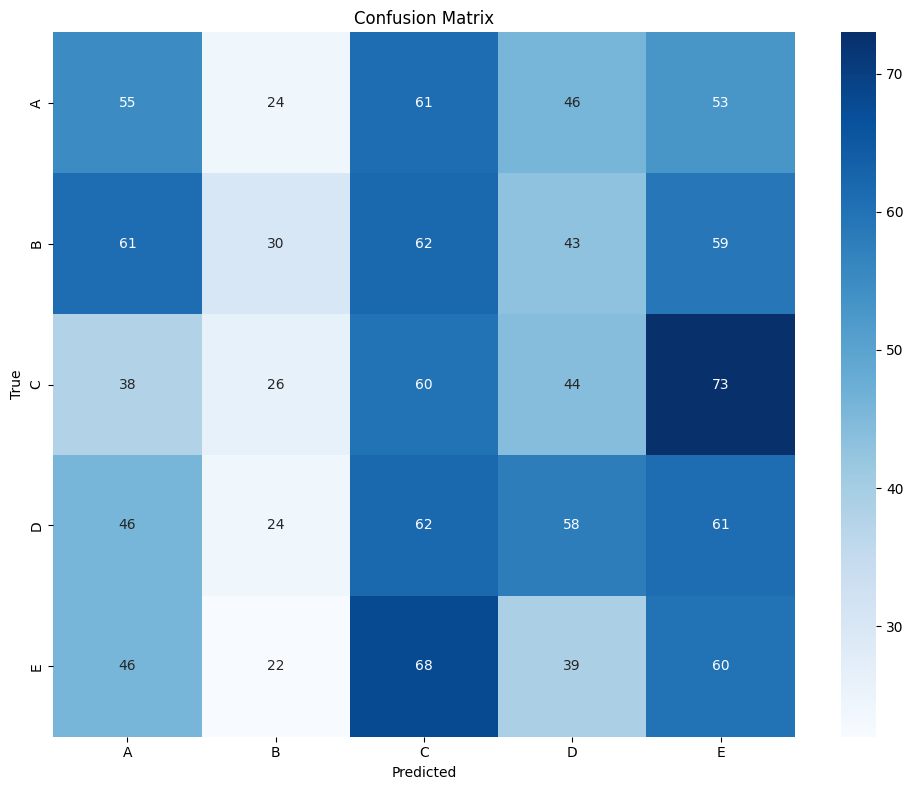

In [17]:
test_data = CommonsenseQADataset(test_dataset, word_to_idx)

print(f"Test dataset size: {len(test_data)}")

test_loader = DataLoader(test_data, batch_size=batch_size)

# Evaluate on test set
print("\nEvaluating on test set...")
test_acc, predictions, confusion_mat, report = evaluate(emb_model, test_loader)
    
# Log the confusion matrix to wandb
wandb.log({"confusion_matrix": wandb.plot.confusion_matrix(
    probs=None,
    y_true=np.array(list(range(5))),
    preds=np.array(list(range(5))),
    class_names=['A', 'B', 'C', 'D', 'E'],
    title="Confusion Matrix")
})
    
# Save predictions to file
with open('test_predictions.txt', 'w') as f:
    for pred in predictions:
        f.write(f"{pred}\n")
    
print(f"Test predictions saved to test_predictions.txt")
    
# Close wandb
wandb.finish()

## RNN Training

In [21]:
# Model parameters
embedding_type = "word2vec"
rnn_type = "gru"  # Options: 'lstm', 'gru'
learning_rate = 1e-3
batch_size = 256
num_epochs = 30
hidden_size = 256
num_layers = 2
dropout_rate = 0.3
freeze_embeddings = True
model_name = f'{rnn_type}-{embedding_type}'
    
# Create a unique run name
run_name = f'{model_name}-{time.strftime("%Y%m%d-%H%M%S")}'
    
# Initialize wandb with your custom function
initialize_wandb_run(
    run_name=run_name,
    embedding_type=embedding_type,
    learning_rate=learning_rate,
    batch_size=batch_size,
    num_epochs=num_epochs,
    rnn_type=rnn_type
)
    
# Create embedding matrix from word2vec (reuse from first architecture)
word_to_idx, embedding_matrix = create_embedding_matrix_from_gensim()
print(f"Created embedding matrix with shape: {embedding_matrix.shape}")
    
# Create datasets
train_data = CommonsenseQADataset(train_dataset, word_to_idx)
val_data = CommonsenseQADataset(validation_dataset, word_to_idx)

print(f"Train dataset size: {len(train_data)}")
print(f"Validation dataset size: {len(val_data)}")
    
# Create data loaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)
    
# Initialize model
rnn_model = RNNClassifier(
    embedding_matrix,
    hidden_size=hidden_size,
    num_layers=num_layers,
    rnn_type=rnn_type,
    dropout_rate=dropout_rate,
    freeze_embeddings=freeze_embeddings
)
    
# Log model architecture to wandb
wandb.config.update({
    "embedding_dim": wv.vector_size,
    "hidden_size": hidden_size,
    "num_rnn_layers": num_layers,
    "rnn_type": rnn_type,
    "dropout_rate": dropout_rate,
    "freeze_embeddings": freeze_embeddings,
    "model_type": "RNNClassifier"
})
wandb.watch(rnn_model)
    
# Define optimizer and loss function
optimizer = optim.Adam(rnn_model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()
    
# Train the model (reuse the train function from the first architecture)
train(rnn_model, train_loader, val_loader, optimizer, criterion, model_name, num_epochs=num_epochs)


Created embedding matrix with shape: (3000002, 300)
Train dataset size: 8741
Validation dataset size: 1000
Epoch 1/30, Train Loss: 1.6113, Train Acc: 0.2012, Val Loss: 1.6077, Val Acc: 0.2310
Saved new best model with validation accuracy: 0.2310
Epoch 2/30, Train Loss: 1.5961, Train Acc: 0.2480, Val Loss: 1.6088, Val Acc: 0.2210
Epoch 3/30, Train Loss: 1.5480, Train Acc: 0.3018, Val Loss: 1.6551, Val Acc: 0.2140
Epoch 4/30, Train Loss: 1.4745, Train Acc: 0.3623, Val Loss: 1.7262, Val Acc: 0.2240
Epoch 5/30, Train Loss: 1.4017, Train Acc: 0.4089, Val Loss: 1.7743, Val Acc: 0.2080
Epoch 6/30, Train Loss: 1.3239, Train Acc: 0.4590, Val Loss: 1.8048, Val Acc: 0.2120
Epoch 7/30, Train Loss: 1.2382, Train Acc: 0.4988, Val Loss: 1.9257, Val Acc: 0.2190
Epoch 8/30, Train Loss: 1.1420, Train Acc: 0.5463, Val Loss: 2.0807, Val Acc: 0.2010
Epoch 9/30, Train Loss: 1.0549, Train Acc: 0.5844, Val Loss: 2.2286, Val Acc: 0.1980
Epoch 10/30, Train Loss: 0.9675, Train Acc: 0.6256, Val Loss: 2.3702, Val 

Test dataset size: 1221

Evaluating RNN model on test set...
Test Accuracy: 0.2203

Classification Report:
              precision    recall  f1-score   support

           A       0.14      0.00      0.01       239
           B       0.23      0.53      0.32       255
           C       0.20      0.02      0.03       241
           D       0.28      0.14      0.19       251
           E       0.20      0.40      0.27       235

    accuracy                           0.22      1221
   macro avg       0.21      0.22      0.16      1221
weighted avg       0.21      0.22      0.16      1221



epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test_accuracy,▁
train_acc,▁▁▂▂▃▃▄▄▄▅▅▆▆▆▇▇▇▇▇███████████
train_loss,███▇▇▇▆▆▅▅▅▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,█▆▅▇▄▅▆▃▂▃▃▂▄▄▁▄▂▃▄▃▂▃▂▅▃▄▃▃▄▃
val_loss,▁▁▁▁▁▁▁▂▂▂▂▂▃▃▄▄▅▅▅▆▆▆▇▇▇▇█▇██
epoch,29
test_accuracy,0.22031
train_acc,0.9833
train_loss,0.05963
val_acc,0.202


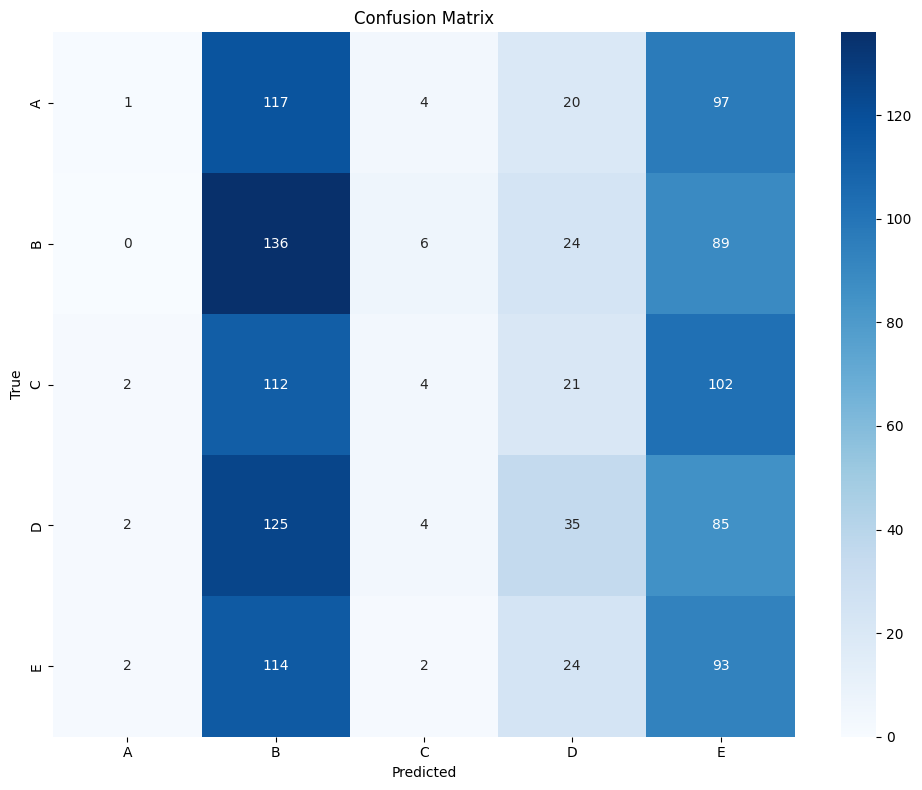

In [22]:
# Load the best model for evaluation
rnn_model.load_state_dict(torch.load(f'best_{model_name}_model.pt'))

# Create the test dataset and loader
test_data = CommonsenseQADataset(test_dataset, word_to_idx)
test_loader = DataLoader(test_data, batch_size=batch_size)
    
print(f"Test dataset size: {len(test_data)}")
    
# Evaluate on test set
print("\nEvaluating RNN model on test set...")
test_acc, predictions, confusion_mat, report = evaluate(rnn_model, test_loader)
    
# Log the confusion matrix to wandb
wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix(
        probs=None,
        y_true=np.array(list(range(5))),
        preds=np.array(list(range(5))),
        class_names=['A', 'B', 'C', 'D', 'E'],
        title="Confusion Matrix"
    )
})

wandb.finish()

# Interpretation

## Word Embedding